# 07 — User Activity Heatmap: Days and Hours

## What this notebook does

Visualizes commit activity for each individual student across days of
the week and hours of the day using two heatmaps stacked vertically.

## Data

- **Source:** `checking-logs.sqlite` → table `checker`
- **Filtered:** only real students (`uid LIKE 'user_%'`)
- **Aggregation:** commit count per user grouped by day of week and by hour

## Key steps

1. Query commit counts grouped by `uid` and `day_of_week`
2. Query commit counts grouped by `uid` and `hour`
3. Pivot both into matrices: rows = users, columns = days/hours
4. Sort users by total commit count descending
5. Reorder day columns in natural week order (Monday → Sunday)
6. Fill missing hour columns with 0 to ensure all 24 hours are present
7. Plot two heatmaps with colorbars using `imshow` and `make_axes_locatable`

## Result

Two heatmaps showing individual activity patterns. The most active student
is **user_2** by days and **user_20** by hours. Friday is the most active
day overall. The most active hour for the top user is **21:00 for user_4**.

## Tools

`pandas` · `sqlite3` · `matplotlib` · `mpl_toolkits`

In [51]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

conn = sqlite3.connect('../data/checking-logs.sqlite')

In [52]:
day_of_week_commits = pd.io.sql.read_sql("""
                                      SELECT c.uid, strftime('%w', c.timestamp) AS day_of_week, COUNT(*) as commits
                                      FROM checker AS c
                                      WHERE c.uid LIKE 'user_%'
                                      GROUP BY c.uid, day_of_week
                                      """, 
                                      conn,)
                                      
days = {'0': 'Sunday', '1': 'Monday', '2': 'Tuesday', '3': 'Wednesday', '4': 'Thursday', '5': 'Friday', '6': 'Saturday'}
day_of_week_commits['day_of_week'] = day_of_week_commits['day_of_week'].map(days)
day_of_week_commits.head()

,uid,day_of_week,commits
0,user_0,Monday,3
1,user_1,Sunday,43
2,user_1,Wednesday,1
3,user_1,Thursday,39
4,user_1,Saturday,1


In [53]:
hour_commits = pd.io.sql.read_sql("""
                                  SELECT c.uid, strftime("%H", c.timestamp) AS hour, COUNT(*) AS commits
                                  FROM checker AS c
                                  WHERE c.uid LIKE 'user_%'
                                  GROUP BY c.uid, hour
                                  """,
                                  conn)
hour_commits

,uid,hour,commits
0,user_0,17,3
1,user_1,12,1
2,user_1,16,1
3,user_1,17,8
4,user_1,19,21
...,...,...,...
303,user_8,16,14
304,user_8,17,7
305,user_8,19,7
306,user_8,20,1


In [54]:
pivot_days = day_of_week_commits.pivot(index='uid', columns='day_of_week', values='commits')
pivot_hours = hour_commits.pivot(index='uid', columns='hour', values='commits')

In [55]:
pivot_days['total'] = pivot_days.sum(axis=1)
pivot_days = pivot_days.sort_values('total', ascending=False).drop('total', axis=1)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_days = pivot_days[days_order]

pivot_hours['total'] = pivot_hours.sum(axis=1)
pivot_hours = pivot_hours.sort_values('total', ascending=False).drop('total', axis=1)
pivot_hours.columns = pivot_hours.columns.astype(int)
pivot_hours = pivot_hours.reindex(columns=range(24), fill_value=0)


In [56]:
print(pivot_days.info())
print(pivot_days.head(3))


<class 'pandas.DataFrame'>
Index: 30 entries, user_4 to user_0
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Monday     18 non-null     float64
 1   Tuesday    19 non-null     float64
 2   Wednesday  16 non-null     float64
 3   Thursday   27 non-null     float64
 4   Friday     11 non-null     float64
 5   Saturday   21 non-null     float64
 6   Sunday     26 non-null     float64
dtypes: float64(7)
memory usage: 1.9+ KB
None
day_of_week  Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
uid                                                                        
user_4         35.0     86.0       33.0     108.0    61.0       NaN    45.0
user_14        50.0     87.0        NaN      17.0     NaN      79.0    26.0
user_2         24.0    131.0       32.0       4.0     NaN      31.0    13.0


In [57]:
print(pivot_hours.info())
print(pivot_hours.head(3))

<class 'pandas.DataFrame'>
Index: 30 entries, user_4 to user_0
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       4 non-null      float64
 1   1       1 non-null      float64
 2   2       30 non-null     int64  
 3   3       2 non-null      float64
 4   4       30 non-null     int64  
 5   5       3 non-null      float64
 6   6       2 non-null      float64
 7   7       8 non-null      float64
 8   8       13 non-null     float64
 9   9       11 non-null     float64
 10  10      14 non-null     float64
 11  11      18 non-null     float64
 12  12      15 non-null     float64
 13  13      16 non-null     float64
 14  14      23 non-null     float64
 15  15      22 non-null     float64
 16  16      21 non-null     float64
 17  17      21 non-null     float64
 18  18      21 non-null     float64
 19  19      24 non-null     float64
 20  20      20 non-null     float64
 21  21      27 non-null     float64
 22  22      14 

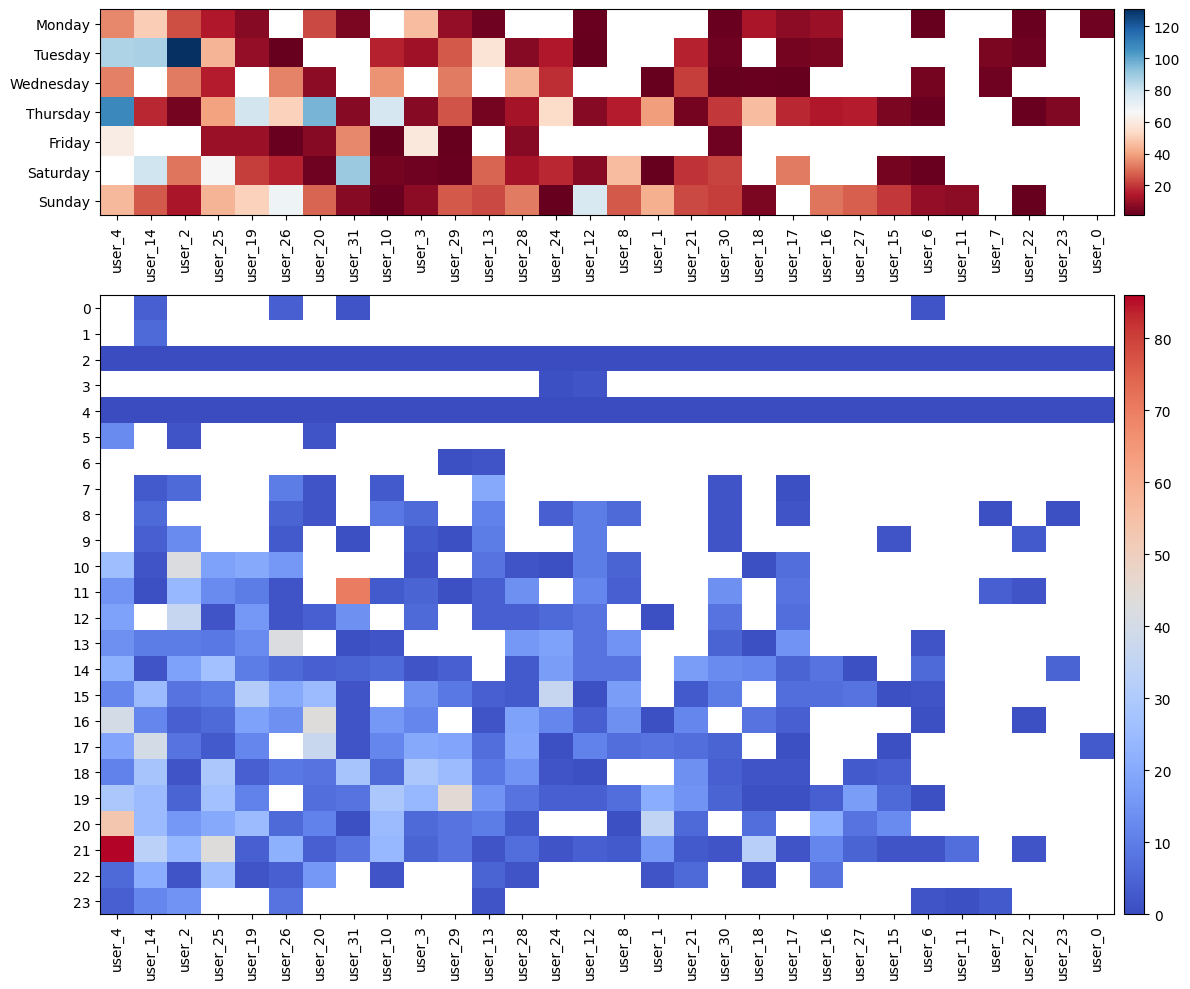

In [58]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 3]})

im1 = ax1.imshow(pivot_days.T, aspect='auto', cmap='RdBu')
ax1.set_yticks(range(len(pivot_days.columns)))
ax1.set_yticklabels(pivot_days.columns)
ax1.set_xticks(range(len(pivot_days.index)))
ax1.set_xticklabels(pivot_days.index, rotation=90)

divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im1, cax=cax1)

im2 = ax2.imshow(pivot_hours.T, aspect='auto', cmap='coolwarm')
ax2.set_yticks(range(len(pivot_hours.columns)))
ax2.set_yticklabels(pivot_hours.columns)
ax2.set_xticks(range(len(pivot_hours.index)))
ax2.set_xticklabels(pivot_hours.index, rotation=90)

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im2, cax=cax2)

plt.tight_layout()
plt.show()

In [59]:
conn.close()